#**Alzheimer Detection**

In [ ]:
pip install tensorflow

In [ ]:
# 1. Import Libraries
import os, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# 2. Unzip and Organize Dataset into a DataFrame
extract_dir = "/content/extracted_images"
os.makedirs(extract_dir, exist_ok=True)

# List of zip files (upload these into your Colab working directory)
zip_files = ["MildDemented.zip", "ModerateDemented.zip", "NonDemented.zip", "VeryMildDemented.zip"]

for zf in zip_files:
    with zipfile.ZipFile(zf, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

filepaths, labels = [], []
dict_list = [
    os.path.join(extract_dir, "MildDemented"),
    os.path.join(extract_dir, "ModerateDemented"),
    os.path.join(extract_dir, "NonDemented"),
    os.path.join(extract_dir, "VeryMildDemented")
]
class_labels = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

for i, j in enumerate(dict_list):
    flist = os.listdir(j)
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Alzheimer_df = pd.DataFrame({"filepaths": filepaths, "labels": labels})
print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())

                                           filepaths        labels
0  /content/extracted_images\MildDemented\00046ff...  MildDemented
1  /content/extracted_images\MildDemented\000cdcc...  MildDemented
2  /content/extracted_images\MildDemented\0013ad5...  MildDemented
3  /content/extracted_images\MildDemented\0015bdf...  MildDemented
4  /content/extracted_images\MildDemented\001f15e...  MildDemented
labels
NonDemented         9600
MildDemented        8960
VeryMildDemented    8960
ModerateDemented    6464
Name: count, dtype: int64


In [ ]:
Alzheimer_df.shape

(33984, 2)

In [ ]:
# 3. Train/Validation/Test Split
train_df, test_df = train_test_split(Alzheimer_df, test_size=0.15, stratify=Alzheimer_df["labels"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df["labels"], random_state=42)

print("Train size:", len(train_df), "Val size:", len(val_df), "Test size:", len(test_df))

Train size: 24553 Val size: 4333 Test size: 5098


In [ ]:
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)
print(train_df.shape)

(24553, 2)
(5098, 2)
(4333, 2)
(24553, 2)


In [ ]:
# 4. Image Generators (with Augmentation)
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepaths", y_col="labels", target_size=IMG_SIZE,
    class_mode="categorical", batch_size=BATCH_SIZE, shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col="filepaths", y_col="labels", target_size=IMG_SIZE,
    class_mode="categorical", batch_size=BATCH_SIZE, shuffle=True
)
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col="filepaths", y_col="labels", target_size=IMG_SIZE,
    class_mode="categorical", batch_size=BATCH_SIZE, shuffle=False
)

Found 24553 validated image filenames belonging to 4 classes.
Found 4333 validated image filenames belonging to 4 classes.
Found 5098 validated image filenames belonging to 4 classes.


In [ ]:
classes=list(train_gen.class_indices.keys())
print (classes)

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [ ]:
def show_knee_images(image_gen):
    test_dict = test_gen.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()

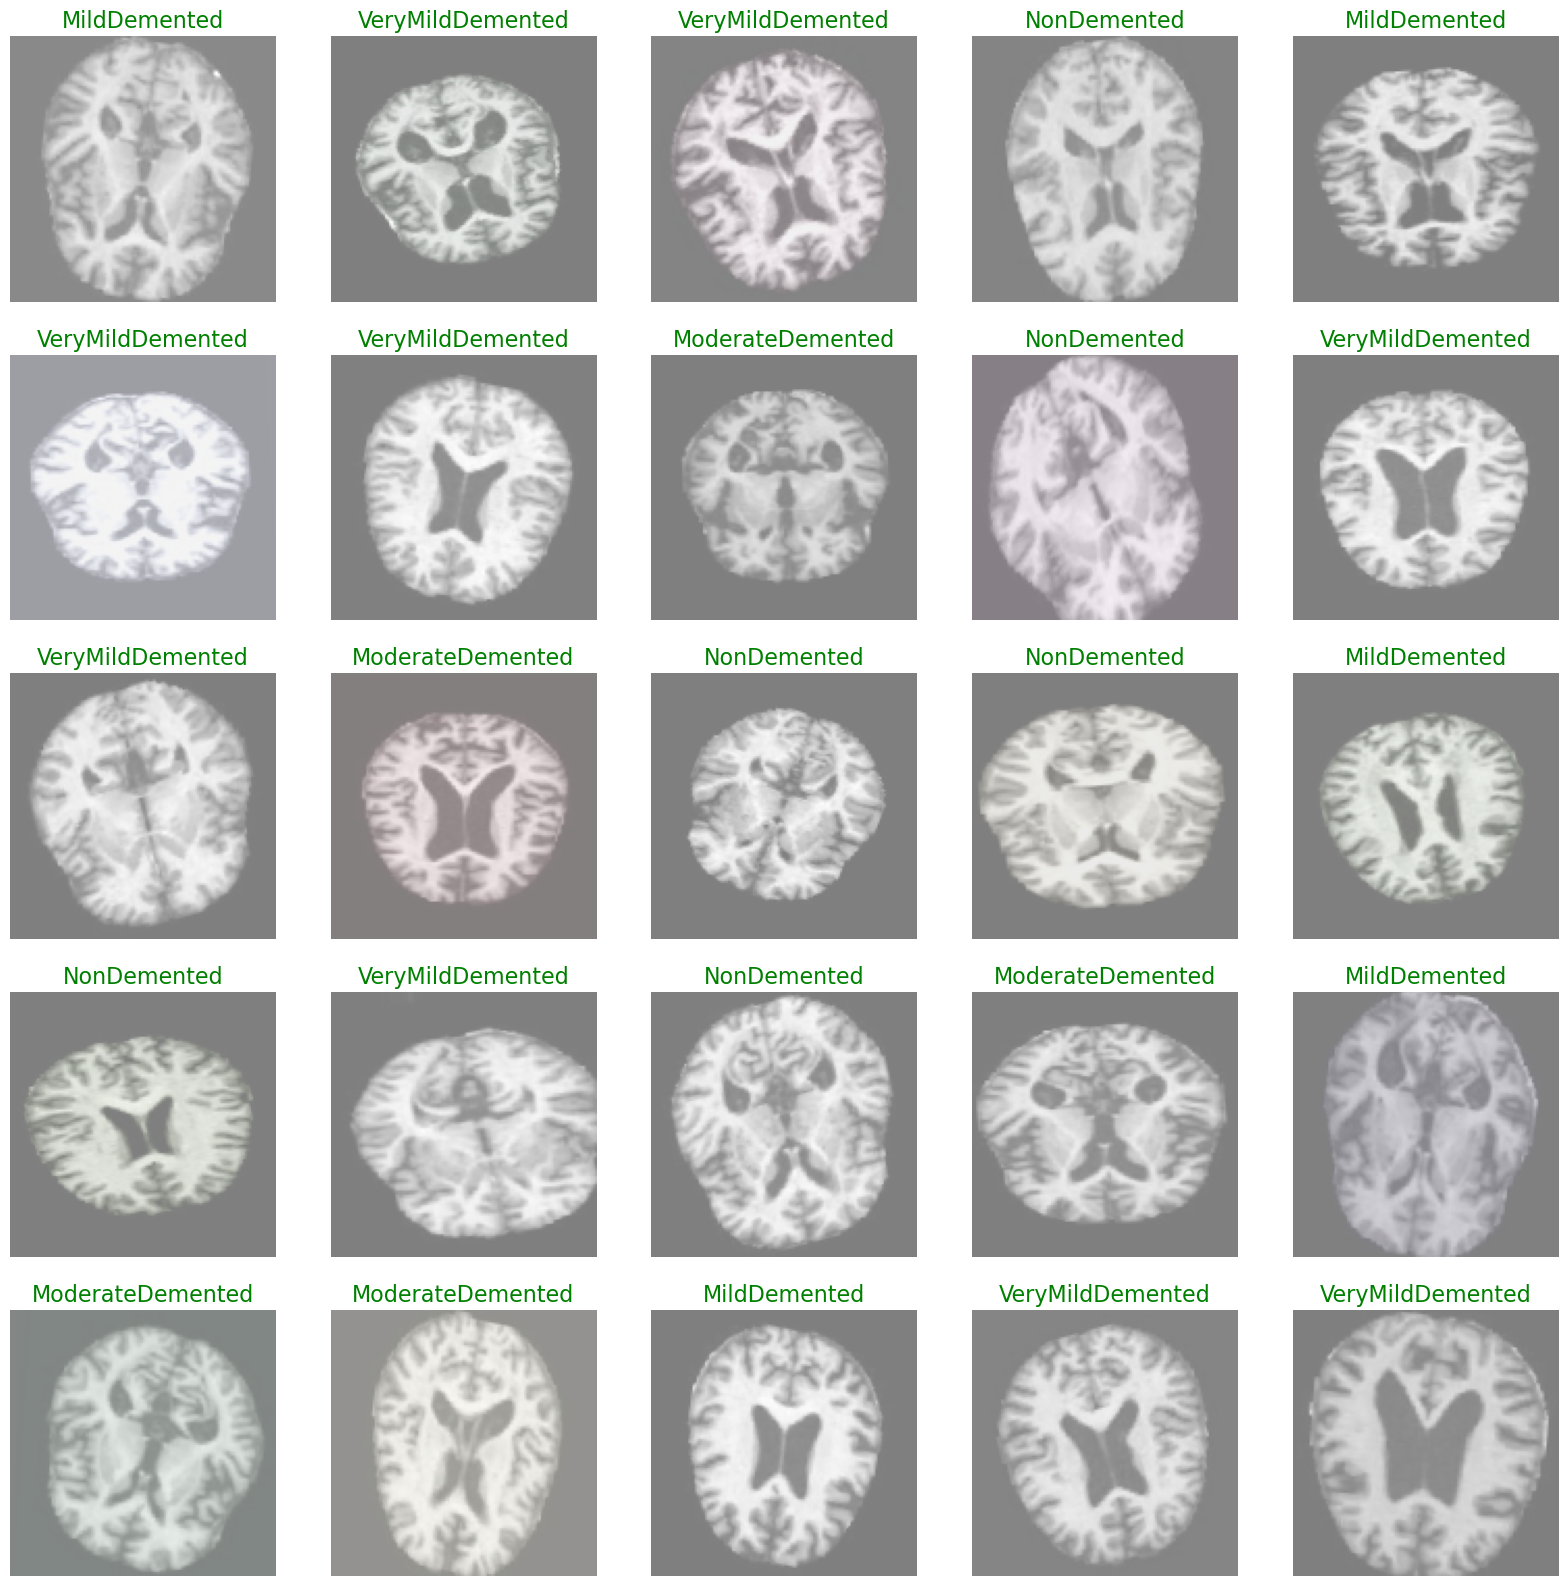

In [ ]:
show_knee_images(train_gen)

In [ ]:
# 5. Baseline CNN Model
baseline_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(4, activation="softmax")
])

baseline_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])
baseline_model.summary()

# Train baseline
history_baseline = baseline_model.fit(train_gen, validation_data=val_gen, epochs=20)

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.3731 - loss: 1.3786  

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


768/768 ━━━━━━━━━━━━━━━━━━━━ 492s 639ms/step - accuracy: 0.4611 - loss: 1.1565 - val_accuracy: 0.6090 - val_loss: 0.8637
Epoch 2/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 279s 364ms/step - accuracy: 0.5959 - loss: 0.8827 - val_accuracy: 0.6351 - val_loss: 0.7660
Epoch 3/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 277s 360ms/step - accuracy: 0.6380 - loss: 0.7933 - val_accuracy: 0.6651 - val_loss: 0.7195
Epoch 4/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 277s 360ms/step - accuracy: 0.6592 - loss: 0.7401 - val_accuracy: 0.6944 - val_loss: 0.6517
Epoch 5/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 279s 363ms/step - accuracy: 0.6751 - loss: 0.7091 - val_accuracy: 0.6988 - val_loss: 0.6447
Epoch 6/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 317s 356ms/step - accuracy: 0.6934 - loss: 0.6693 - val_accuracy: 0.7323 - val_loss: 0.5809
Epoch 7/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 444s 515ms/step - accuracy: 0.7102 - loss: 0.6448 - val_accuracy: 0.7459 - val_loss: 0.5635
Epoch 8/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 288s 373ms/step - accuracy: 0.7190 - loss: 0.62

In [ ]:
# 6. Transfer Learning (ResNet50 Fine-tuning)
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(128,128,3))
for layer in base_model.layers[:-10]:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

transfer_model = Model(inputs=base_model.input, outputs=output)
transfer_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])
transfer_model.summary()

# Train transfer model
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=3)

history_transfer = transfer_model.fit(
    train_gen, validation_data=val_gen, epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 31,977,604 (121.98 MB)

 Trainable params: 12,855,556 (49.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

Epoch 1/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 1008s 1s/step - accuracy: 0.4250 - loss: 1.2259 - val_accuracy: 0.5495 - val_loss: 1.0152 - learning_rate: 1.0000e-04
Epoch 2/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 1010s 1s/step - accuracy: 0.5157 - loss: 1.0628 - val_accuracy: 0.5444 - val_loss: 0.9689 - learning_rate: 1.0000e-04
Epoch 3/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 1002s 1s/step - accuracy: 0.5463 - loss: 0.9946 - val_accuracy: 0.5747 - val_loss: 0.9243 - learning_rate: 1.0000e-04
Epoch 4/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 1058s 1s/step - accuracy: 0.5616 - loss: 0.9506 - val_accuracy: 0.5721 - val_loss: 0.9570 - learning_rate: 1.0000e-04
Epoch 5/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 993s 1s/step - accuracy: 0.5771 - loss: 0.9205 - val_accuracy: 0.5532 - val_loss: 0.9961 - learning_rate: 1.0000e-04
Epoch 6/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 980s 1s/step - accuracy: 0.5900 - loss: 0.8943 - val_accuracy: 0.6019 - val_loss: 0.8871 - learning_rate: 1.0000e-04
Epoch 7/20
768/768 ━━━━━━━━━━━━━━━━━━━━ 979s 1s/step -

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


160/160 ━━━━━━━━━━━━━━━━━━━━ 157s 965ms/step
Classes (index order): ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Number of test samples: 5098
Test Accuracy:  0.7407
Test Precision: 0.7605
Test Recall:    0.7588
Test F1-score:  0.7593

Classification Report:

                  precision    recall  f1-score   support

    MildDemented       0.80      0.74      0.77      1344
ModerateDemented       0.98      1.00      0.99       970
     NonDemented       0.70      0.72      0.71      1440
VeryMildDemented       0.56      0.58      0.57      1344

        accuracy                           0.74      5098
       macro avg       0.76      0.76      0.76      5098
    weighted avg       0.74      0.74      0.74      5098



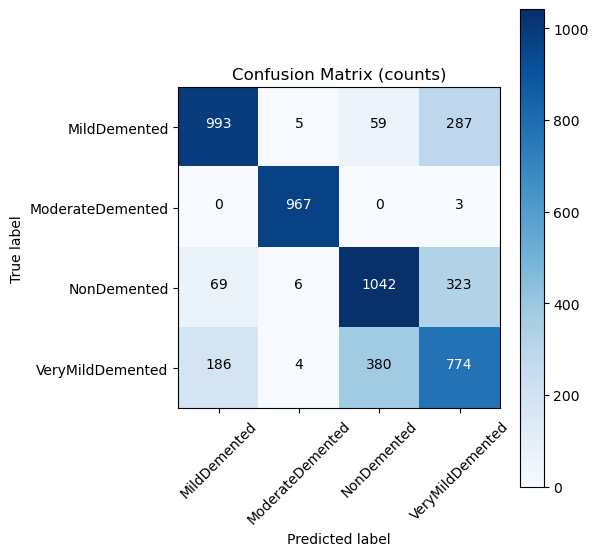

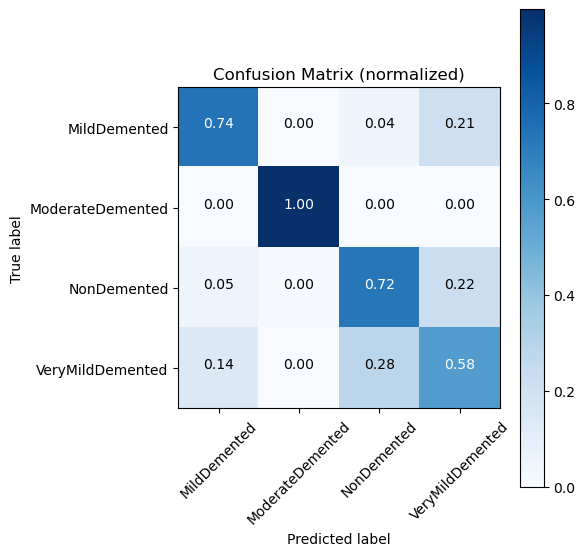


ROC AUC (macro, OVR): 0.9273


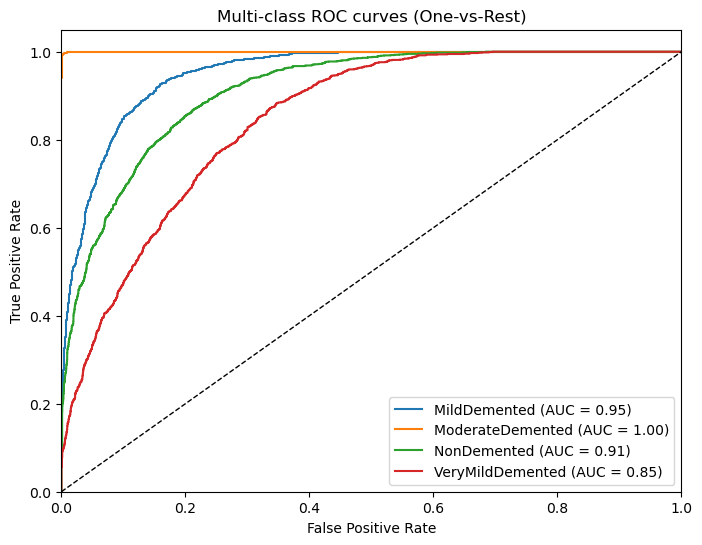

In [ ]:
import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import itertools


# 8. Detailed Evaluation on Test Set
# Get predictions and true labels
# Predict probabilities for the entire test set
y_prob = transfer_model.predict(test_gen, verbose=1)  # shape: (n_samples, n_classes)
y_pred = np.argmax(y_prob, axis=1)

# True labels (as integers)
# test_gen.classes holds the integer labels in the same order as predictions
y_true = test_gen.classes  # numpy array

# Class names (ordered by index)
# test_gen.class_indices is a dict: {class_name: index}
class_indices = test_gen.class_indices
# Convert to index->name list
idx_to_class = [None] * len(class_indices)
for k, v in class_indices.items():
    idx_to_class[v] = k

n_classes = len(idx_to_class)
print("Classes (index order):", idx_to_class)
print("Number of test samples:", len(y_true))

# Standard metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1-score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=idx_to_class, zero_division=0))

# Confusion matrix (raw and normalized)
cm = confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_to_plot = cmn
    else:
        cm_to_plot = cm

    plt.figure(figsize=(6,6))
    plt.imshow(cm_to_plot, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm_to_plot.max() / 2.
    for i, j in itertools.product(range(cm_to_plot.shape[0]), range(cm_to_plot.shape[1])):
        plt.text(j, i, format(cm_to_plot[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm_to_plot[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, idx_to_class, normalize=False, title='Confusion Matrix (counts)')
plot_confusion_matrix(cm, idx_to_class, normalize=True, title='Confusion Matrix (normalized)')

# ROC & AUC (multi-class, One-vs-Rest)
# Binarize true labels for multi-class ROC
y_true_binarized = label_binarize(y_true, classes=list(range(n_classes)))  # shape (n_samples, n_classes)

try:
    roc_auc = roc_auc_score(y_true_binarized, y_prob, average='macro', multi_class='ovr')
    print(f"\nROC AUC (macro, OVR): {roc_auc:.4f}")
except Exception as e:
    print("Could not compute ROC AUC:", e)
    roc_auc = None

# Plot ROC curves for each class
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{idx_to_class[i]} (AUC = {roc_auc_i:.2f})")
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()